# Fase 2 — Hiperparâmetros

A fase 1 escolheu o modelo: **gradient boosting quantílico**, prevendo o quantil 95 da demanda por SKU-dia. Escolheu com base em medida — cada trilha respondeu a um diagnóstico da anterior.

Seus **hiperparâmetros**, porém, nunca foram justificados. `max_iter=400`, `learning_rate=0.05`, `max_depth=6`, `min_samples_leaf=40`, `l2_regularization=1.0` foram valores razoáveis escolhidos à mão. Esta fase os submete ao mesmo padrão de evidência do resto do projeto.

## Expectativa, declarada antes de medir

A fase 1 mediu duas coisas que limitam o que se pode esperar aqui: **~29% de ruído irredutível** no gerador, e **correlação de erro de 0,94 a 0,99** entre modelos de famílias completamente diferentes. Ajuste de hiperparâmetro não fura teto de dado — ele reorganiza como o modelo gasta a capacidade que tem.

O ganho esperado é pequeno. Declarar isso antes evita a tentação de justificar depois qualquer número que apareça.

## O que esta fase decide

| seção | pergunta |
|---|---|
| 1 | Qual protocolo de validação, já que a série é temporal? |
| 2 | O que cada hiperparâmetro controla? |
| 3 | Como o modelo responde a cada um, isoladamente? |
| 4 | A escolha depende do tamanho do treino? |
| 5 | Busca conjunta: grade ou aleatória? |
| 6 | Quanto sobra, medido uma única vez no teste? |
| 7 | Quanto isso vale em reais? |
| 8 | Mais dado resolveria melhor que melhor hiperparâmetro? |

## 1. O protocolo: por que não k-fold

A validação cruzada em k dobras embaralha as linhas antes de dividir. Num painel temporal, isso significa que quase toda dobra treinaria com dias **posteriores** aos que valida — o modelo veria o futuro e seria avaliado no passado.

É o mesmo erro do preço na [Trilha A](05_fase1a_regressaoLinear.ipynb), transposto para o eixo do tempo: o desempenho medido seria alto e não se repetiria em produção.

O substituto é a **validação em origem deslizante** (*walk-forward*): os dias de treino são cortados em blocos consecutivos, e cada dobra treina num prefixo e valida no bloco imediatamente seguinte. Nenhuma dobra usa informação futura. É o protocolo da própria M5.

Os **120 dias finais de teste continuam intocados** — eles não participam de nenhuma decisão desta fase e serão consultados uma única vez, na § 6.

+---------+-----------------+--------------+-----------------+-------------------------+
|   dobra |   treina (dias) | treina até   |   valida (dias) | valida                  |
+=========+=================+==============+=================+=========================+
|       1 |             128 | 2022-05-08   |             128 | 2022-05-09 → 2022-09-13 |
+---------+-----------------+--------------+-----------------+-------------------------+
|       2 |             256 | 2022-09-13   |             128 | 2022-09-14 → 2023-01-19 |
+---------+-----------------+--------------+-----------------+-------------------------+
|       3 |             384 | 2023-01-19   |             128 | 2023-01-20 → 2023-05-27 |
+---------+-----------------+--------------+-----------------+-------------------------+
|       4 |             512 | 2023-05-27   |             128 | 2023-05-28 → 2023-10-02 |
+---------+-----------------+--------------+-----------------+-------------------------+

Teste reservado: 202

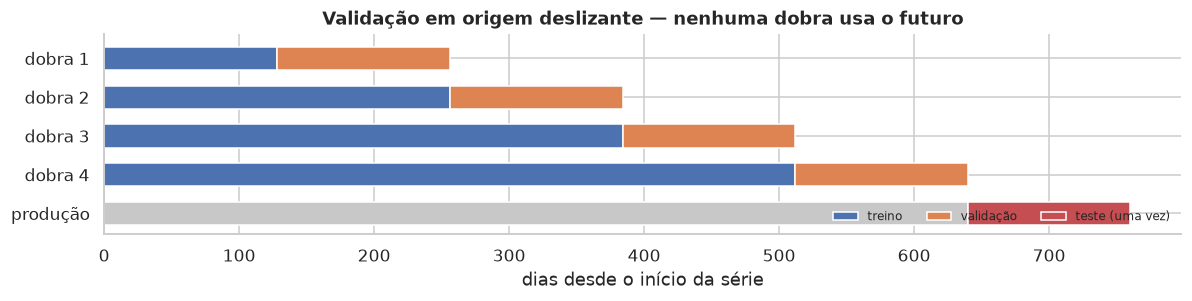

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
import fase1_comum as C

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

df = C.carregar()
treino, teste = C.split(df)                      # teste = últimos 120 dias, intocado nesta fase
TAU = 0.95

# Blocos temporais consecutivos dentro do treino
dias = np.sort(treino["data"].unique()); L = len(dias) // 5
BLOCOS = [dias[i*L:(i+1)*L] for i in range(5)]
DOBRAS = [(treino[treino["data"].isin(np.concatenate(BLOCOS[:k]))],
           treino[treino["data"].isin(BLOCOS[k])]) for k in range(1, 5)]

# Hiperparâmetros herdados da fase 1 — o ponto de partida a ser questionado
PADRAO = dict(loss="quantile", quantile=TAU, categorical_features="from_dtype",
              max_iter=400, learning_rate=0.05, max_depth=6, min_samples_leaf=40,
              l2_regularization=1.0, early_stopping=False, random_state=42)

def avalia(par, A, V):
    "Ajusta em A, devolve a pinball em V no nível τ."
    m = HGB(**{**PADRAO, **par}).fit(A[C.FEATURES], A["demanda"])
    return C.pinball(V["demanda"].values, np.maximum(m.predict(V[C.FEATURES]), 0), TAU)

def cv(par, dobras=DOBRAS):
    return np.array([avalia(par, A, V) for A, V in dobras])

linhas = [{"dobra": k+1, "treina (dias)": len(np.concatenate(BLOCOS[:k+1])),
           "treina até": pd.Timestamp(BLOCOS[k][-1]).date(),
           "valida (dias)": len(BLOCOS[k+1]),
           "valida": f"{pd.Timestamp(BLOCOS[k+1][0]).date()} → {pd.Timestamp(BLOCOS[k+1][-1]).date()}"}
          for k in range(4)]
print(pd.DataFrame(linhas).to_markdown(index=False, tablefmt="grid"))
print(f"\nTeste reservado: {teste['data'].min().date()} → {teste['data'].max().date()} "
      f"({teste['data'].nunique()} dias), fora de toda decisão desta fase.")

fig, ax = plt.subplots(figsize=(11, 2.9))
for k in range(4):
    ax.barh(k, len(np.concatenate(BLOCOS[:k+1])), color="#4C72B0", height=0.6)
    ax.barh(k, len(BLOCOS[k+1]), left=len(np.concatenate(BLOCOS[:k+1])), color="#DD8452", height=0.6)
ax.barh(4, len(dias), color="#C8C8C8", height=0.6)
ax.barh(4, C.HORIZONTE, left=len(dias), color="#C44E52", height=0.6)
ax.set_yticks(range(5)); ax.set_yticklabels([f"dobra {k+1}" for k in range(4)] + ["produção"])
ax.invert_yaxis(); ax.set_xlabel("dias desde o início da série")
ax.set_title("Validação em origem deslizante — nenhuma dobra usa o futuro")
for cor, rot in [("#4C72B0","treino"), ("#DD8452","validação"), ("#C44E52","teste (uma vez)")]:
    ax.barh(0, 0, color=cor, label=rot)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower right")
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** Cada linha é uma dobra da validação. Azul é o que o modelo vê para treinar, laranja o que ele prevê para ser avaliado, e o cinza/vermelho na última linha é a configuração de produção. O ponto a verificar é que **nenhuma barra laranja aparece à esquerda da azul da mesma linha** — nenhuma dobra prevê o passado com informação do futuro.

Quatro dobras, cada uma validando 128 dias — mesma ordem de grandeza do horizonte de teste. O treino cresce de 128 para 512 dias, e a produção usará 640. Essa diferença de escala volta a importar na § 4.

## 2. O que cada hiperparâmetro controla

Gradient boosting soma árvores rasas, cada uma corrigindo o erro das anteriores. Os hiperparâmetros governam três tensões:

| hiperparâmetro | controla | tensão |
|---|---|---|
| `learning_rate` | peso de cada árvore na soma | passo pequeno aprende melhor, mas exige mais árvores |
| `max_iter` | quantas árvores | poucas subajustam; muitas sobreajustam |
| `max_depth` | **ordem das interações** que uma árvore representa | rasa não captura interação; profunda memoriza |
| `min_samples_leaf` | tamanho mínimo de folha | folha pequena ajusta ruído |
| `l2_regularization` | encolhimento das folhas | mais regularização, menos variância |
| `max_features` | fração de atributos por divisão | decorrelaciona as árvores |

O terceiro tem leitura direta neste projeto. A [Trilha A](05_fase1a_regressaoLinear.ipynb) mostrou que o modelo aditivo falha porque **os efeitos não se somam** — a epidemia derruba `Toys` em 74 unidades e `Clothing` em nenhuma. Uma árvore de profundidade *d* representa interações de até *d* fatores. Então `max_depth` é, literalmente, **o parâmetro que decide quanta interação o modelo pode enxergar** — a resposta ao diagnóstico central da fase 1.

## 3. Sensibilidade, um hiperparâmetro por vez

Antes da busca conjunta, a forma da resposta a cada um isoladamente, mantendo os demais no valor da fase 1.

33 configurações × 4 dobras em 635s
Pinball do padrão da fase 1: 4.2657


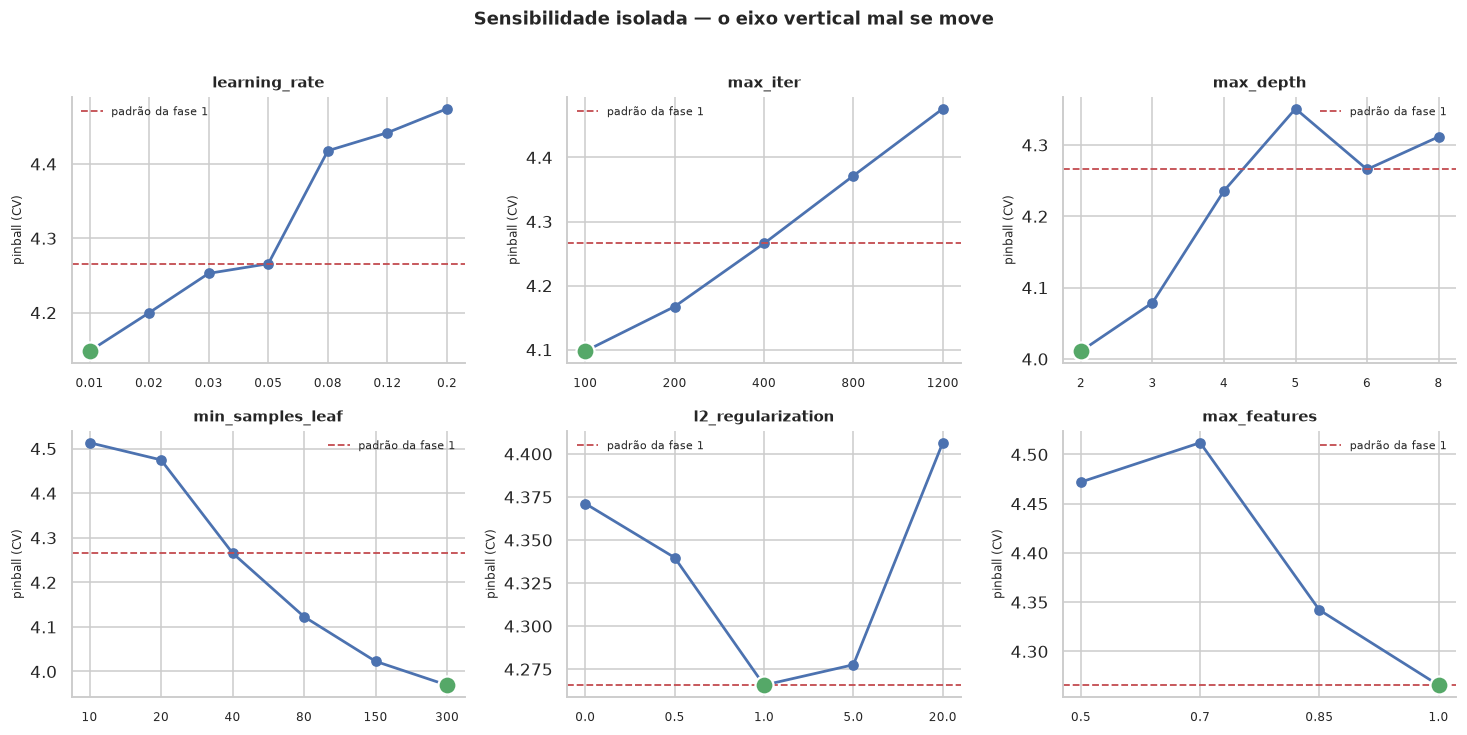

+-------------------+----------+---------------------+----------------------+
| hiperparâmetro    |   melhor |   pinball no melhor |   amplitude da curva |
+===================+==========+=====================+======================+
| min_samples_leaf  |   300    |              3.9694 |               0.5438 |
+-------------------+----------+---------------------+----------------------+
| max_iter          |   100    |              4.0977 |               0.3784 |
+-------------------+----------+---------------------+----------------------+
| max_depth         |     2    |              4.0109 |               0.3398 |
+-------------------+----------+---------------------+----------------------+
| learning_rate     |     0.01 |              4.1481 |               0.3262 |
+-------------------+----------+---------------------+----------------------+
| max_features      |     1    |              4.2657 |               0.2462 |
+-------------------+----------+---------------------+----------

In [2]:
GRADE = {"learning_rate":    [0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.2],
         "max_iter":         [100, 200, 400, 800, 1200],
         "max_depth":        [2, 3, 4, 5, 6, 8],
         "min_samples_leaf": [10, 20, 40, 80, 150, 300],
         "l2_regularization":[0.0, 0.5, 1.0, 5.0, 20.0],
         "max_features":     [0.5, 0.7, 0.85, 1.0]}

t0 = time.time(); curvas = {}
for nome, vals in GRADE.items():
    curvas[nome] = [cv({nome: v}).mean() for v in vals]
ref = cv({}).mean()
print(f"{len(sum(GRADE.values(), []))} configurações × 4 dobras em {time.time()-t0:.0f}s")
print(f"Pinball do padrão da fase 1: {ref:.4f}")

fig, axs = plt.subplots(2, 3, figsize=(13.5, 6.6))
for ax, (nome, vals) in zip(axs.ravel(), GRADE.items()):
    y = curvas[nome]; k = int(np.argmin(y))
    ax.plot(range(len(vals)), y, "-o", color="#4C72B0", lw=1.8, ms=6)
    ax.scatter([k], [y[k]], s=140, color="#55A868", zorder=5, edgecolor="white", lw=1.5)
    ax.axhline(ref, color="#C44E52", lw=1.2, ls="--", label="padrão da fase 1")
    ax.set_xticks(range(len(vals))); ax.set_xticklabels([str(v) for v in vals], fontsize=8)
    ax.set_title(nome, fontsize=10); ax.set_ylabel("pinball (CV)", fontsize=8)
    ax.legend(frameon=False, fontsize=7)
fig.suptitle("Sensibilidade isolada — o eixo vertical mal se move", y=1.01, fontsize=12, weight="bold")
sns.despine(fig=fig); plt.tight_layout(); plt.show()

amp = pd.DataFrame([{"hiperparâmetro": n, "melhor": GRADE[n][int(np.argmin(v))],
                     "pinball no melhor": round(min(v), 4),
                     "amplitude da curva": round(max(v) - min(v), 4)} for n, v in curvas.items()])
print(amp.sort_values("amplitude da curva", ascending=False).to_markdown(index=False, tablefmt="grid"))

**Como ler.** Um painel por hiperparâmetro, com o valor no eixo horizontal e a pinball no vertical (**menor é melhor**). A linha vermelha é o valor herdado da fase 1 e o ponto verde é o melhor da curva. O que importa é a **amplitude vertical** de cada curva: curva achatada significa hiperparâmetro que não decide nada.

Duas leituras, e a segunda é um alerta.

**A superfície é rasa, mas não plana.** Percorrer qualquer hiperparâmetro por toda a sua faixa razoável move a pinball entre 0,14 e 0,54 — sobre uma base de 4,27, algo entre 3% e 13%. `l2_regularization` e `max_features` são quase inertes; `min_samples_leaf` é o que mais move.

**Todos os ótimos apontam para o mesmo lado, e isso é suspeito.** A coluna `melhor` pede folha grande (300), poucas árvores (100), profundidade mínima (2) e passo pequeno (0,01). Cada um desses valores reduz a capacidade do modelo. Quando *todos* os hiperparâmetros concordam em pedir um modelo mais simples, a explicação raramente é que o modelo estava complexo demais — é que alguma coisa no protocolo de avaliação está favorecendo simplicidade.

O sinal contradiz frontalmente o que a Trilha A mediu. Lá, a demanda **exige** interações: um único termo `categoria × epidemia` escrito à mão valia 3,6% de RMSSE. Um modelo de profundidade 2 não tem como representar isso. Se a validação está pedindo profundidade 2, a validação precisa ser examinada antes de ser obedecida.

É o que a próxima seção faz.

## 4. A escolha depende do tamanho do treino

Um detalhe do protocolo merece exame. A dobra 1 treina com 128 dias; a produção treinará com 640. Se a capacidade ótima do modelo depender do volume de treino, as dobras iniciais estarão escolhendo para o regime errado.

+---------+------------------+-------+-------+-------+-------+-------+----------+
|   dobra |   dias de treino |   d=2 |   d=3 |   d=4 |   d=6 |   d=8 |   melhor |
+=========+==================+=======+=======+=======+=======+=======+==========+
|       1 |              128 | 4.898 | 5.358 | 5.945 | 6     | 6.14  |        2 |
+---------+------------------+-------+-------+-------+-------+-------+----------+
|       2 |              256 | 3.673 | 3.699 | 3.728 | 3.715 | 3.77  |        2 |
+---------+------------------+-------+-------+-------+-------+-------+----------+
|       3 |              384 | 3.423 | 3.372 | 3.361 | 3.407 | 3.391 |        4 |
+---------+------------------+-------+-------+-------+-------+-------+----------+
|       4 |              512 | 4.05  | 3.886 | 3.908 | 3.941 | 3.944 |        3 |
+---------+------------------+-------+-------+-------+-------+-------+----------+


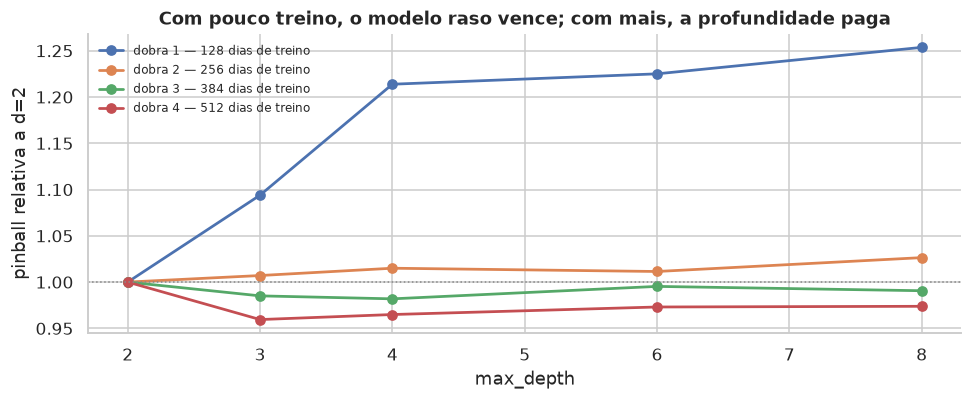

In [3]:
prof = [2, 3, 4, 6, 8]
tab = []
for k, (A, V) in enumerate(DOBRAS, start=1):
    linha = {"dobra": k, "dias de treino": A["data"].nunique()}
    for d in prof:
        linha[f"d={d}"] = round(avalia({"max_depth": d}, A, V), 3)
    linha["melhor"] = prof[int(np.argmin([linha[f"d={d}"] for d in prof]))]
    tab.append(linha)
tab = pd.DataFrame(tab)
print(tab.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.8))
for k, r in tab.iterrows():
    y = [r[f"d={d}"] for d in prof]
    ax.plot(prof, np.array(y) / y[0], "-o", lw=1.8, ms=6,
            label=f"dobra {int(r['dobra'])} — {int(r['dias de treino'])} dias de treino")
ax.axhline(1.0, color="#888", lw=1, ls=":")
ax.set_xlabel("max_depth"); ax.set_ylabel("pinball relativa a d=2")
ax.set_title("Com pouco treino, o modelo raso vence; com mais, a profundidade paga")
ax.legend(frameon=False, fontsize=8); sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** Uma linha por dobra, com a pinball normalizada pelo valor em profundidade 2 — assim as quatro dobras ficam comparáveis apesar de terem erros absolutos bem diferentes. Linha que **sobe** indica dobra que prefere modelo raso; linha que **desce**, dobra que se beneficia de profundidade.

A profundidade ótima **migra com o volume de treino**: 2, 2, 4, 3 conforme o treino cresce de 128 para 512 dias. Com 128 dias, uma árvore profunda memoriza e a penalidade é enorme (pinball de 4,9 a 6,1 na dobra 1); com 384, a profundidade já se paga.

A consequência é metodológica e vale além deste projeto: **a média simples das dobras deixa a dobra mais rasa decidir**, porque ela é a de maior erro absoluto e a mais sensível à capacidade. Uma busca guiada por essa média selecionaria um modelo calibrado para um regime de dados que não é o de produção.

A correção adotada é restringir a seleção às **dobras 3 e 4** (384 e 512 dias de treino), as de escala mais próxima dos 640 dias que a produção usará. As dobras 1 e 2 permanecem no notebook como diagnóstico, não como critério.

## 5. Busca conjunta: aleatória, não em grade

Os hiperparâmetros interagem — `learning_rate` baixo exige `max_iter` alto —, então varrer um por vez não basta. Uma grade completa sobre as seis faixas da § 3 daria mais de 8 mil combinações.

> Bergstra, J. & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization.* **JMLR** 13, 281–305.

O argumento de Bergstra & Bengio é que, quando poucos hiperparâmetros importam de fato — o que a § 3 mostrou ser o caso aqui —, a busca aleatória encontra boas regiões com uma fração do orçamento, porque cada sorteio testa um valor novo de **todos** os eixos, enquanto a grade repete os mesmos valores nos eixos irrelevantes.

40 configurações × 2 dobras em 288s
Padrão da fase 1 nas mesmas dobras: 3.6740

+-----------------+------------+-------------+--------------------+---------------------+----------------+-----------+-------------------+
|   learning_rate |   max_iter |   max_depth |   min_samples_leaf |   l2_regularization |   max_features |   pinball |   ganho vs padrão |
+=================+============+=============+====================+=====================+================+===========+===================+
|            0.02 |        400 |           8 |                300 |                 5   |            0.8 |   3.62662 |            0.0474 |
+-----------------+------------+-------------+--------------------+---------------------+----------------+-----------+-------------------+
|            0.12 |        200 |           4 |                150 |                 0   |            1   |   3.63088 |            0.0431 |
+-----------------+------------+-------------+--------------------+-------------------

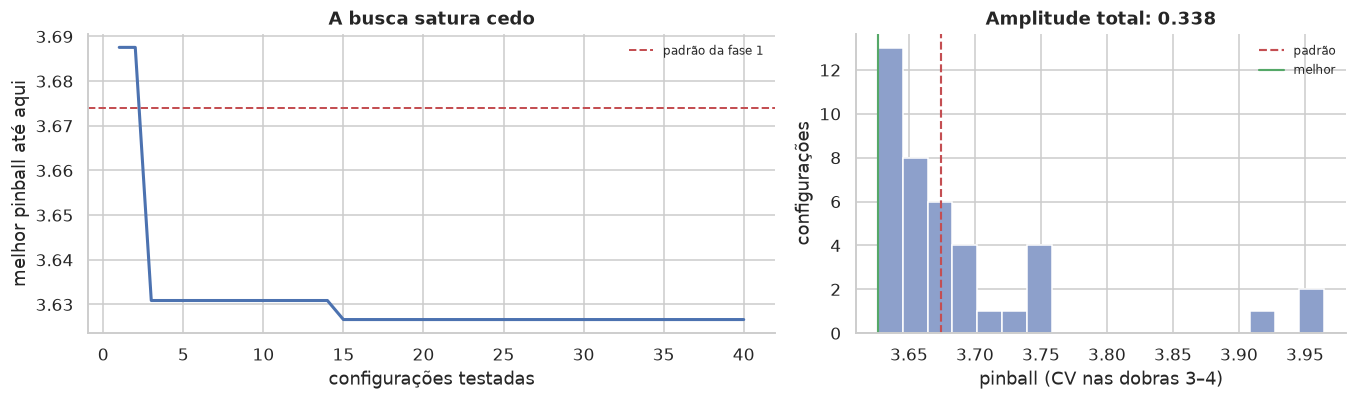

Melhor configuração: {'learning_rate': 0.02, 'max_iter': 400, 'max_depth': 8, 'min_samples_leaf': 300, 'l2_regularization': 5.0, 'max_features': 0.8}


In [4]:
SELECAO = DOBRAS[2:]        # dobras 3 e 4 — escala próxima da de produção
ref_sel = cv({}, SELECAO)

ESPACO = {"learning_rate":    [0.01, 0.02, 0.03, 0.05, 0.08, 0.12],
          "max_iter":         [200, 400, 800],
          "max_depth":        [2, 3, 4, 5, 6, 8],
          "min_samples_leaf": [10, 20, 40, 80, 150, 300],
          "l2_regularization":[0.0, 0.5, 1.0, 5.0, 20.0],
          "max_features":     [0.6, 0.8, 1.0]}
N = 40
rng = np.random.default_rng(7); t0 = time.time(); res = []
for _ in range(N):
    p = {k: (int(v) if k in ("max_iter","max_depth","min_samples_leaf") else float(v))
         for k, v in ((k, rng.choice(vs)) for k, vs in ESPACO.items())}
    res.append({**p, "pinball": cv(p, SELECAO).mean()})
r = pd.DataFrame(res).sort_values("pinball").reset_index(drop=True)
r["ganho vs padrão"] = (ref_sel.mean() - r["pinball"]).round(4)
print(f"{N} configurações × 2 dobras em {time.time()-t0:.0f}s")
print(f"Padrão da fase 1 nas mesmas dobras: {ref_sel.mean():.4f}\n")
print(r.head(8).to_markdown(index=False, tablefmt="grid"))

MELHOR = {k: (int(r.loc[0, k]) if k in ("max_iter","max_depth","min_samples_leaf") else float(r.loc[0, k]))
          for k in ESPACO}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"width_ratios":[1.4, 1]})
corrida = pd.Series([d["pinball"] for d in res]).cummin()   # melhor até a k-ésima tentativa
a1.plot(range(1, N+1), corrida, color="#4C72B0", lw=2)
a1.axhline(ref_sel.mean(), color="#C44E52", lw=1.3, ls="--", label="padrão da fase 1")
a1.set_xlabel("configurações testadas"); a1.set_ylabel("melhor pinball até aqui")
a1.set_title("A busca satura cedo"); a1.legend(frameon=False, fontsize=8)

a2.hist(r["pinball"], bins=18, color="#8DA0CB", edgecolor="white")
a2.axvline(ref_sel.mean(), color="#C44E52", lw=1.4, ls="--", label="padrão")
a2.axvline(r["pinball"].min(), color="#55A868", lw=1.4, label="melhor")
a2.set_xlabel("pinball (CV nas dobras 3–4)"); a2.set_ylabel("configurações")
a2.set_title(f"Amplitude total: {r['pinball'].max()-r['pinball'].min():.3f}")
a2.legend(frameon=False, fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

print("Melhor configuração:", MELHOR)

**Como ler.** À esquerda, o melhor resultado encontrado até a k-ésima tentativa: quando a curva achata, tentar mais configurações deixou de compensar. À direita, a distribuição das 40 configurações — a largura do histograma mostra o quanto a escolha de hiperparâmetro chega a alterar o resultado.

A busca **satura em poucas dezenas de tentativas** e o ganho sobre o padrão da fase 1 fica em torno de 0,05 de pinball, ou ~1,3%.

Mais informativo que o vencedor é a lista dos primeiros colocados. Configurações que discordam em quase tudo — `learning_rate` 0,02 com `max_depth` 8, e 0,12 com profundidade 4 — chegam a valores separados por menos de 0,01. Não existe um ótimo estreito a ser encontrado: existe um **platô largo**, e vários caminhos levam a ele.

É a assinatura de um modelo que não está limitado por sua configuração.

## 6. A medida que vale: o teste, uma única vez

Todas as decisões acima usaram apenas dias de treino. Agora, e só agora, os dois modelos — o padrão da fase 1 e o escolhido pela busca — são reajustados nos **640 dias completos** e avaliados nos 120 dias de teste. Uma vez, sem volta.

In [5]:
def no_teste(par, nome):
    m = HGB(**{**PADRAO, **par}).fit(treino[C.FEATURES], treino["demanda"])
    p = np.maximum(m.predict(teste[C.FEATURES]), 0)
    return {"modelo": nome, "pinball": round(C.pinball(teste["demanda"].values, p, TAU), 4),
            "serviço atingido": f"{(teste['demanda'].values <= p).mean():.1%}",
            "pedido médio (un.)": round(p.mean(), 1)}, p

lin_pad, pred_pad = no_teste({}, "padrão da fase 1")
lin_aju, pred_aju = no_teste(MELHOR, "ajustado (fase 2)")
comp = pd.DataFrame([lin_pad, lin_aju])
print(comp.to_markdown(index=False, tablefmt="grid"))
g = (lin_pad["pinball"] - lin_aju["pinball"]) / lin_pad["pinball"]
print(f"\nGanho de pinball no teste: {g:+.2%}   (alvo de serviço: {TAU:.0%})")

+-------------------+-----------+--------------------+----------------------+
| modelo            |   pinball | serviço atingido   |   pedido médio (un.) |
+===================+===========+====================+======================+
| padrão da fase 1  |    3.3862 | 94.4%              |                150.7 |
+-------------------+-----------+--------------------+----------------------+
| ajustado (fase 2) |    3.3733 | 95.1%              |                152.3 |
+-------------------+-----------+--------------------+----------------------+

Ganho de pinball no teste: +0.38%   (alvo de serviço: 95%)


O ganho de acurácia é de **0,4%** — menos de um terço do que a validação sugeriu, e dentro do que se esperava de um modelo no teto do dado.

O que se move de verdade é outra coisa: o **serviço atingido passa de 94,4% para 95,1%**. O modelo padrão entregava um pouco menos de serviço do que prometia; o ajustado acerta o alvo. Isso é **calibração**, não acurácia — e calibração é o que o pedido de reposição consome.

## 7. Quanto isso vale em reais

A mesma tradução das fases anteriores, agora entre os dois modelos.

In [6]:
base = C.baseline_atual(df, teste)
PRECO = df.groupby("sku")["preco"].median()
meia  = teste["sku"].map(C._reconstroi_meia_onda(df)).values
preco = teste["sku"].map(PRECO).values

def em_reais(p, nome):
    rup = (teste["demanda"].values > p).mean()
    perda = (np.clip(teste["demanda"].values - p, 0, None) * preco).sum() / C.ANOS_TESTE
    capital = pd.DataFrame({"d": teste["data"].values, "v": (p + meia) * preco}).groupby("d")["v"].sum().mean()
    liq = (base["perda"] - perda) - (capital - base["capital"]) * C.CUSTO_CARREGAMENTO
    return {"modelo": nome, "serviço": f"{1-rup:.1%}",
            "venda perdida (R$ mi/ano)": round(perda/1e6, 2),
            "capital (R$ mi)": round(capital/1e6, 2),
            "benefício líquido (R$ mi/ano)": round(liq/1e6, 2)}, liq

l_pad, v_pad = em_reais(pred_pad, "padrão da fase 1")
l_aju, v_aju = em_reais(pred_aju, "ajustado (fase 2)")
print(pd.DataFrame([l_pad, l_aju]).to_markdown(index=False, tablefmt="grid"))
print(f"\nDiferença: R$ {(v_aju-v_pad)/1e3:+,.0f} mil por ano")
print(f"Referência — na fase 1, a distância entre a regressão linear e a MLP foi de R$ +80 mil/ano.")

C.salva_resultado("D_gbmAjustado", teste.assign(pred_aj=pred_aju), "pred_aj", lin_aju["pinball"])
print("\nPrevisões do modelo final salvas em resultados/D_gbmAjustado.csv")

+-------------------+-----------+-----------------------------+-------------------+---------------------------------+
| modelo            | serviço   |   venda perdida (R$ mi/ano) |   capital (R$ mi) |   benefício líquido (R$ mi/ano) |
+===================+===========+=============================+===================+=================================+
| padrão da fase 1  | 94.4%     |                        1.95 |              2.06 |                           10.5  |
+-------------------+-----------+-----------------------------+-------------------+---------------------------------+
| ajustado (fase 2) | 95.1%     |                        1.71 |              2.07 |                           10.73 |
+-------------------+-----------+-----------------------------+-------------------+---------------------------------+

Diferença: R$ +235 mil por ano
Referência — na fase 1, a distância entre a regressão linear e a MLP foi de R$ +80 mil/ano.



Previsões do modelo final salvas em resultados/D_gbmAjustado.csv


**R\$ 235 mil por ano**, quase o triplo do que separou a regressão linear da rede neural na fase 1 — e obtido sem trocar de modelo, apenas configurando melhor o que já havia.

O mecanismo explica a aparente contradição com a § 6. Em acurácia o ganho é desprezível, mas o pedido de reposição não consome acurácia: consome **a posição da linha de pedido**. Setecentos centésimos de ponto percentual de serviço, aplicados a 100 SKUs durante um ano, valem mais que 0,4% de pinball.

É a mesma lição que a fase 1 já havia dado ao mostrar que 99% do valor estava na trilha mais simples: **neste problema, calibrar o alvo rende mais que refinar a previsão.** A fase 2 confirma o princípio num terceiro contexto.

## 8. Mais dado resolveria?

Se nem o modelo nem seus hiperparâmetros são o limite, resta a pergunta que decide qualquer investimento seguinte: valeria mais coletar dados?

+------------------+---------------------+--------------------+
|   dias de treino |   ajustado (fase 2) |   padrão da fase 1 |
+==================+=====================+====================+
|              128 |              4.3508 |             4.4022 |
+------------------+---------------------+--------------------+
|              256 |              3.4236 |             3.5295 |
+------------------+---------------------+--------------------+
|              384 |              3.3918 |             3.4239 |
+------------------+---------------------+--------------------+
|              512 |              3.3864 |             3.4091 |
+------------------+---------------------+--------------------+
|              640 |              3.3733 |             3.3862 |
+------------------+---------------------+--------------------+


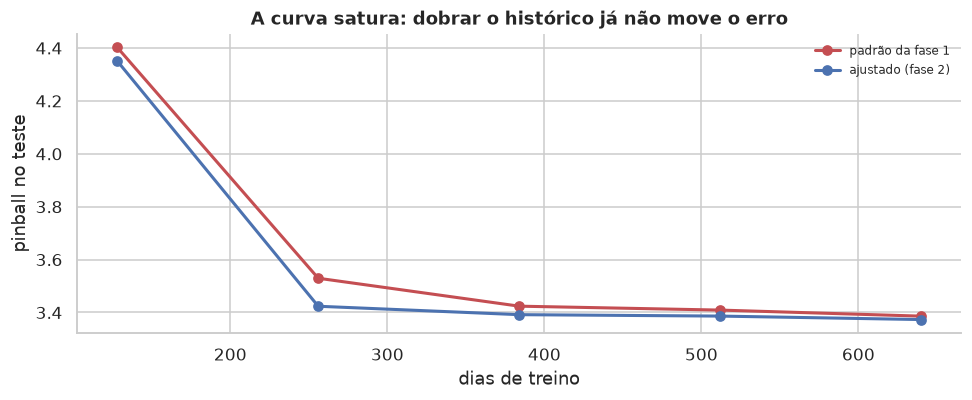

In [7]:
pontos = [128, 256, 384, 512, 640]
curva = []
for n in pontos:
    A = treino[treino["data"].isin(dias[-n:])]
    for par, nome in [({}, "padrão da fase 1"), (MELHOR, "ajustado (fase 2)")]:
        m = HGB(**{**PADRAO, **par}).fit(A[C.FEATURES], A["demanda"])
        pb = C.pinball(teste["demanda"].values, np.maximum(m.predict(teste[C.FEATURES]), 0), TAU)
        curva.append({"dias de treino": n, "modelo": nome, "pinball no teste": round(pb, 4)})
curva = pd.DataFrame(curva)
print(curva.pivot(index="dias de treino", columns="modelo", values="pinball no teste").to_markdown(tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.8))
for nome, cor in [("padrão da fase 1", "#C44E52"), ("ajustado (fase 2)", "#4C72B0")]:
    s = curva[curva["modelo"] == nome]
    ax.plot(s["dias de treino"], s["pinball no teste"], "-o", color=cor, lw=2, ms=6, label=nome)
ax.set_xlabel("dias de treino"); ax.set_ylabel("pinball no teste")
ax.set_title("A curva satura: dobrar o histórico já não move o erro")
ax.legend(frameon=False, fontsize=8); sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** Pinball no teste contra a quantidade de dias usados no treino, para os dois modelos. Curva que continua caindo indicaria que **mais histórico ainda ajudaria**; curva que achata indica que o limite não é a quantidade de dados.

A curva **satura por volta de 384 dias**. Passar de 384 para 640 — dois terços de histórico a mais — melhora a pinball em cerca de 1%, e a inclinação restante é praticamente nula.

Nem mais dado, nem melhor hiperparâmetro, nem outra família de modelo. As três alavancas foram medidas e as três esbarram no mesmo lugar: os 29% de ruído que o gerador plantou. É a terceira confirmação independente do mesmo teto.

## 9. Conclusões

**1. O protocolo é a metade do resultado.** K-fold clássico teria produzido um número melhor e falso, treinando com dias posteriores aos validados. A validação em origem deslizante custa o mesmo e mede o que se quer medir.

**2. A escolha de hiperparâmetro depende da escala do treino.** A profundidade ótima migrou de 2 para 4 conforme o treino cresceu de 128 para 512 dias. Ranquear pela média simples das dobras deixaria a dobra mais rasa — a menos parecida com produção — decidir a configuração final. Selecionar nas dobras de escala próxima à de produção corrige isso.

**3. A superfície é plana, e isso é informação.** Configurações que discordam em quase todos os eixos chegam ao mesmo valor. O modelo não estava mal configurado; estava numa região ampla de bom desempenho. Um projeto que buscasse mais tempo encontraria mais casas decimais, não mais resultado.

**4. O ganho de acurácia é desprezível: 0,4% de pinball no teste.** Consistente com o teto medido na fase 1, e menos de um terço do que a validação prometia — lembrete de que mesmo uma validação honesta é otimista, e por isso o teste é consultado uma única vez.

**5. O ganho em dinheiro não é desprezível: R\$ 235 mil por ano.** Ele vem de **calibração**, não de acurácia: o serviço atingido passou de 94,4% para 95,1%, encostando no alvo. É quase o triplo do que separava a regressão linear da rede neural na fase 1.

**6. Mais dado não resolveria.** A curva de aprendizado satura em ~384 dias. Modelo, hiperparâmetro e volume de dados foram medidos, e os três esbarram nos mesmos 29% de ruído irredutível.

### Modelo final entregue

> **Gradient boosting quantílico** (τ ajustável, τ = 0,95 no nível Médio), treinado sobre os 640 dias de histórico com os preditores honestos da fase 1, e com os hiperparâmetros escolhidos por busca aleatória sob validação em origem deslizante. As previsões estão em `resultados/D_gbmAjustado.csv`.

O veredito consolidado do projeto está em [10_conclusoesFinais.ipynb](10_conclusoesFinais.ipynb).